In [149]:
#implementacion de perceptron multicapa con backpropagation
import torch
import numpy as np
from graphviz import Digraph

In [150]:
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def show_graph(root, format='svg', rankdir='LR'):
    assert rankdir in ['LR', 'TB']
    nodes, edges= trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir})

    for n in nodes:
        dot.node(name=str(id(n)), label="{%s | data %.4f | grad %.4f }" % (n.name, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot

import os
os.environ['PATH'] += r';C:\Program Files\Graphviz\bin'

class Value():
    def __init__(self, data, _children=(), _op='', name=''):
        self.data = data
        self.name = name
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self._backward = lambda: None #funcion que se va a llamar para propagar el gradiente hacia atras

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
    
        def _backward(): #cuando se llama a backward en el nodo de salida, se va a llamar a esta funcion para propagar el gradiente hacia atras
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward
        return out
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += out.grad * other.data
            other.grad += out.grad * self.data
        out._backward = _backward
        return out
    
    def __pow__(self, other): #funcion para elevar a una potencia, solo soporta int/float por ahora
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data ** other, (self,), f'**{other}')
        def _backward():
            self.grad += out.grad * other * (self.data ** (other - 1))
        out._backward = _backward
        return out
    
    def __truediv__(self, other):
        return self * other**-1
    
    def exp(self): #funcion exponencial
        out = np.exp(self.data)
        out = Value(out, _children=(self,), _op='exp')
        def _backward():
            self.grad += out.grad * out.data
        out._backward = _backward
        return out
    
    def tanh(self): #funcion tangente hiperbólica
        x = self.data
        t = (np.e ** (2*x) - 1) / (np.e ** (2*x) + 1)
        out = Value(t, _children=(self,), _op='tanh')
        def _backward():
            self.grad += out.grad * (1 - t**2)
        out._backward = _backward
        return out
    
    def backward(self): #funcion para propagar el gradiente hacia atras, se llama en el nodo de salida
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

    def __radd__(self, other):
        return self + other
    
    def __rmul__(self, other):
        return self * other
    
    def __neg__(self):
        return self * -1
    
    def __sub__(self, other):
        return self + (-other)
    
    def __rsub__(self, other):
        return other + (-self)
    
    def __repr__(self):
        return f'Value(data={self.data}, grad={self.grad}, _op="{self._op}", name="{self.name}")'

In [151]:
#perceptron/neurona, no tiene funcion de activacion, no tiene bias
W0 = Value(-.5, name='W0') #pesos
x0 = Value(.5, name='x0')
W1 = Value(-.3, name='W1')
x1 = Value(2, name='x1')
W0x0 = W0 * x0; W0x0.name = 'W0x0'
W1x1 = W1 * x1; W1x1.name = 'W1x1'
yhat = W0x0 + W1x1; yhat.name = 'yhat' #valor predicho de la funcion
yhat = yhat.tanh(); yhat.name = 'tanh(yhat)'
y = Value(.8, name='y') # valor esperado
L = y - yhat; L.name = 'L' #fucion de perdida, diferencia entre el valor real y el predicho
L.backward()
W0.grad

-0.26121149393241616

In [152]:
 #value representa solo un valor, un tensor representa un array de valores, en este caso un array de un solo valor
W0 = torch.tensor(-.5); W0.requires_grad = True #calcula el gradiente de este tensor, es decir, la derivada de la funcion de perdida con respecto a este tensor
x0 = torch.tensor(.5); x0.requires_grad = True
W1 = torch.tensor(-.3); W1.requires_grad = True
x1 = torch.tensor(2.); x1.requires_grad = True
yhat = torch.tanh(W0 * x0 + W1 * x1); #esto calcula el valor predicho de la funcion, en este caso la tangente hiperbólica de la suma ponderada de las entradas
y = torch.tensor(.8); y.requires_grad = True # valor esperado
L = y - yhat #fucion de perdida, diferencia entre el valor real y el predicho
L.backward() #esto calcula el gradiente de L con respecto a W0, W1, x0 y x1
W0.grad

tensor(-0.2612)

In [153]:
class Neuron:
    def __init__(self, nin):
        self.W = [Value(np.random.uniform(-1, 1)) for _ in range(nin)] #pesos, un array de valores aleatorios entre -1 y 1, cada peso corresponde a una entrada de la neurona, el numero de pesos es igual al numero de entradas
        self.b = Value(np.random.uniform(-1, 1)) #bias, un valor que se suma a la salida de la neurona, esto permite que la neurona pueda aprender a activar incluso cuando todas las entradas son cero, puede ser opcional
    def __repr__(self):
        return f"Neuron(nin={len(self.W)})"
    def __call__(self, x): #esto hace que la neurona sea callable, es decir, que se pueda llamar como una funcion, esto es lo que se llama forward pass, es decir, calcular la salida de la neurona dada una entrada
        return sum([wi * xi for wi, xi in zip(self.W, x)], self.b) # esto calcula la salida de la neurona, es decir, la suma ponderada de las entradas mas el bias, esto es lo que se llama la funcion de activacion lineal, luego se puede aplicar una funcion de activacion no lineal como tanh o relu para obtener la salida final de la neurona

    def parameters(self):
        return self.W + [self.b] #esto devuelve una lista de los parametros de la neurona, es decir, los pesos y el bias, esto es lo que se llama los parametros entrenables de la neurona, estos son los parametros que se van a actualizar durante el entrenamiento de la red neuronal

class Layer:
    
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)] #esto crea una capa de neuronas, es decir, un array de neuronas, cada neurona tiene un numero de entradas igual a nin, el numero de neuronas es igual a nout
    
    def __call__(self, x):
        act = [n(x).tanh() for n in self.neurons] #la capa de neuronas puede tener una funcion de activacion, en este caso se va a usar la funcion de activacion lineal, es decir, la salida de la capa es la suma de las salidas de las neuronas, la otra opcion es que cada neurona tenga su propia funcion de activacion, en el caso de querer permitir que el usuario elija la funcion de activacion.
        return act
    
    def __repr__(self):
        return f"Layer of [{', '.join(str(n) for n in self.neurons)}]"
    
    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()] #esto devuelve una lista de los parametros de la capa, es decir, los pesos y el bias de cada neurona, esto es lo que se llama los parametros entrenables de la capa, estos son los parametros que se van a actualizar durante el entrenamiento de la red neuronal

class MLP: #Multi Layer Perceptron, una red neuronal con varias capas de neuronas, cada capa tiene un numero de neuronas, cada neurona tiene un numero de entradas, cada entrada tiene un peso, cada neurona tiene una funcion de activacion, la salida de una capa es la entrada de la siguiente capa
    
    def __init__ (self, nin, nouts):
        self.nin = nin
        self.nouts = nouts
        sz = [nin] + nouts
        #self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))] #esto crea una red neuronal con varias capas, cada capa tiene un numero de neuronas igual a nouts[i], el numero de entradas de la primera capa es igual a nin, el numero de entradas de las siguientes capas es igual al numero de neuronas de la capa anterior
        self.layers = [Layer(a, b) for a, b in zip(sz, sz[1:])] #esto hace lo mismo que la linea anterior pero de una forma mas elegante, zip hace que se itere sobre dos listas al mismo tiempo, en este caso se itera sobre la lista de tamaños de entradas y la lista de tamaños de salidas, esto es lo que se llama un perceptron multicapa
    
    def __call__(self, x):
        for l in self.layers:
            x = l(x)
        return x
    
    def __repr__(self):
        return f"MLP of [{', '.join(str(layer) for layer in self.layers)}]"
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()] #esto devuelve una lista de los parametros de la red neuronal, es decir, los pesos y el bias de cada neurona de cada capa, esto es lo que se llama los parametros entrenables de la red neuronal, estos son los parametros que se van a actualizar durante el entrenamiento de la red neuronal

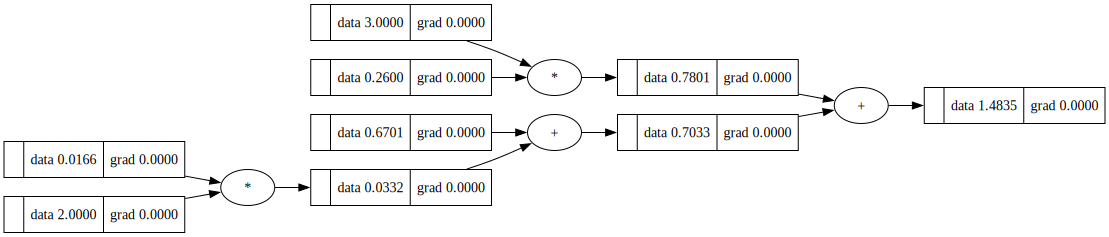

In [154]:
x = [2, 3]
n = Neuron(2)
show_graph(n(x))

In [155]:
model = MLP(2, [3, 3, 1]) #perceptron de 2 entradas, 3 capas ocultas con 3 neuronas cada una, y una capa de salida con 1 neurona
model

MLP of [Layer of [Neuron(nin=2), Neuron(nin=2), Neuron(nin=2)], Layer of [Neuron(nin=3), Neuron(nin=3), Neuron(nin=3)], Layer of [Neuron(nin=3)]]

In [156]:
#show_graph(model([1, 2])[0]) #esto calcula la salida de la red neuronal dada una entrada, en este caso la entrada es un array de 2 valores, el resultado es un array de 1 valor, que es la salida de la red neuronal, esto es lo que se llama el forward pass, es decir, calcular la salida de la red neuronal dada una entrada
model([1, 2])[0].tanh()

Value(data=0.6906354019426071, grad=0.0, _op="tanh", name="")

In [157]:
#entrenamiento de modelo.

np.random.seed(40) #esto hace que los numeros aleatorios sean siempre los mismos, esto es importante para poder reproducir 
#los resultados, si no se pone esto, cada vez que se ejecute el codigo se van a generar numeros aleatorios diferentes, lo 
#que puede hacer que los resultados sean diferentes cada vez que se ejecute el codigo, esto es lo que se llama reproducibilidad
xor = MLP(2, [3, 3, 1]) #esto crea un perceptron multicapa con 2 entradas, 3 capas ocultas con 3 neuronas cada una, y una capa de salida con 1 neurona
xs = [[0, 0], [0, 1], [1, 0], [1, 1]] #esto es lo que se llama un dataset, se compone de un array de entradas, cada entrada es un array de 2 valores.
ys = [0, 1, 1, 0] #esto tambien es un dataset pero de salidas, cada salida es un valor, el numero de salidas es igual al numero de entradas.
xor.parameters() #esto devuelve una lista de los parametros de la red neuronal, es decir, los pesos y el bias de cada neurona de cada capa.

[Value(data=-0.18462594383942776, grad=0.0, _op="", name=""),
 Value(data=-0.8892679197762798, grad=0.0, _op="", name=""),
 Value(data=0.5770697549735053, grad=0.0, _op="", name=""),
 Value(data=-0.4253896304213083, grad=0.0, _op="", name=""),
 Value(data=-0.0992988260654577, grad=0.0, _op="", name=""),
 Value(data=-0.39217538931846896, grad=0.0, _op="", name=""),
 Value(data=0.052799048594290854, grad=0.0, _op="", name=""),
 Value(data=0.24762442576937338, grad=0.0, _op="", name=""),
 Value(data=0.5535509154499147, grad=0.0, _op="", name=""),
 Value(data=0.37248329073291475, grad=0.0, _op="", name=""),
 Value(data=0.9618777263756102, grad=0.0, _op="", name=""),
 Value(data=0.2016321844318263, grad=0.0, _op="", name=""),
 Value(data=0.6279370398859911, grad=0.0, _op="", name=""),
 Value(data=0.41729030432639735, grad=0.0, _op="", name=""),
 Value(data=-0.9449306393549348, grad=0.0, _op="", name=""),
 Value(data=0.8085344344634557, grad=0.0, _op="", name=""),
 Value(data=-0.100190297492

In [158]:
yhats = [xor(x)[0] for x in xs] #esto calcula la salida de la red neuronal dada una entrada, 
#en este caso se calcula la salida de la red neuronal para cada entrada del dataset, el
#resultado es un array de 4 valores, cada valor es la salida de la red neuronal para cada entrada,
#esto es lo que se llama el forward pass, es decir, calcular la salida de la red neuronal dada una entrada
yhats

[Value(data=0.011082209707468916, grad=0.0, _op="tanh", name=""),
 Value(data=0.1193526531019616, grad=0.0, _op="tanh", name=""),
 Value(data=0.06230056664007959, grad=0.0, _op="tanh", name=""),
 Value(data=0.1644186594141305, grad=0.0, _op="tanh", name="")]

In [159]:
#mean squared error
loss = sum([(y - yhat)**2 for y, yhat in zip(ys, yhats)])/4
loss.backward()

In [160]:
# for p in xor.parameters():
#     p.grad = 0.
xor.parameters()

[Value(data=-0.18462594383942776, grad=0.017559925997173265, _op="", name=""),
 Value(data=-0.8892679197762798, grad=0.06410954178952907, _op="", name=""),
 Value(data=0.5770697549735053, grad=0.09317595460576082, _op="", name=""),
 Value(data=-0.4253896304213083, grad=0.030454449763290672, _op="", name=""),
 Value(data=-0.0992988260654577, grad=0.023581076584597665, _op="", name=""),
 Value(data=-0.39217538931846896, grad=0.05542731901868013, _op="", name=""),
 Value(data=0.052799048594290854, grad=-0.005149456591869984, _op="", name=""),
 Value(data=0.24762442576937338, grad=0.007760294504599673, _op="", name=""),
 Value(data=0.5535509154499147, grad=0.005387325029437162, _op="", name=""),
 Value(data=0.37248329073291475, grad=0.007559476685484191, _op="", name=""),
 Value(data=0.9618777263756102, grad=-0.04363464780765407, _op="", name=""),
 Value(data=0.2016321844318263, grad=0.046708834776607436, _op="", name=""),
 Value(data=0.6279370398859911, grad=0.07887180879861538, _op="", n

In [161]:
for p in xor.parameters():
    p.data -= 0.1 * p.grad 
    #esto actualiza los parametros de la red neuronal, es decir, 
    #los pesos y el bias de cada neurona de cada capa, esto es lo que se llama el paso de optimizacion, en este caso se esta usando 
    # el metodo de descenso de gradiente, que consiste en restar al parametro el gradiente multiplicado por una tasa de aprendizaje 
    # (en este caso 0.1), esto hace que el parametro se mueva en la direccion opuesta al gradiente, lo que hace que la funcion de perdida 
    # disminuya, esto es lo que se llama minimizar la funcion de perdida

In [162]:
yhats = [xor(x)[0] for x in xs]
loss = sum([(y - yhat)**2 for y, yhat in zip(ys, yhats)])/4
loss
#stochastic gradient descent, es decir, actualizar los parametros de la red neuronal despues de cada ejemplo del dataset, 
# esto hace que el entrenamiento sea mas rapido, pero puede hacer que el entrenamiento sea mas inestable, es decir, que 
# la funcion de perdida no disminuya de forma monotona, sino que pueda aumentar en algunos pasos, esto es lo que se llama 
# ruido en el entrenamiento, pero a veces este ruido puede ayudar a escapar de los minimos locales y encontrar un minimo global.

Value(data=0.29707494990788974, grad=0.0, _op="*", name="")

In [163]:
#bucle de entrenamiento

#declaracion de modelo
np.random.seed(40)  
xor = MLP(2, [3, 3, 1]) 
xs = [[0, 0], [0, 1], [1, 0], [1, 1]]
ys = [0, 1, 1, 0] 
steps = 1000
lr = 0.01

In [183]:
for _ in range(steps):
    #1. forward pass
    yhats = [xor(x)[0] for x in xs]
    #2. cacular loss function
    loss = sum([(y - yhat)**2 for y, yhat in zip(ys, yhats)])/4
    #3. zero grad
    for p in xor.parameters():
        p.grad = 0.
    #4. backward pass
    loss.backward()
    #5. update weights
    for p in xor.parameters():
        p.data -= lr * p.grad
loss

Value(data=0.005085610350058181, grad=1.0, _op="*", name="")

In [185]:
xor([0, 0]), xor([0, 1]), xor([1, 0]), xor([1, 1])

([Value(data=0.015070291442408935, grad=0.0, _op="tanh", name="")],
 [Value(data=0.932225779148068, grad=0.0, _op="tanh", name="")],
 [Value(data=0.877323549450848, grad=0.0, _op="tanh", name="")],
 [Value(data=0.021394231627008445, grad=0.0, _op="tanh", name="")])

In [186]:
#ejercicio 1: implementar el parametro bias en Neuron y Layer para poder crear neuronas sin sesgo.(mirar la implementacion de Michigrad)

class Neuron:
    def __init__(self, nin, bias=True):
        self.W = [Value(np.random.uniform(-1, 1)) for _ in range(nin)] 
        self.b = Value(0) if bias else None #Neurona sin sesgo
    def __repr__(self):
        return f"Neuron(nin={len(self.W)}, bias={self.b is not None})"
    def __call__(self, x): 
        act = sum([wi * xi for wi, xi in zip(self.W, x)], Value(0)) 
        return act + self.b if self.b is not None else act

    def parameters(self):
        return self.W + ([self.b] if self.b is not None else []) 
    
class Layer:
    
    def __init__(self, nin, nout, bias=True):
        self.neurons = [Neuron(nin, bias=bias) for _ in range(nout)] 
    
    def __call__(self, x):
        act = [n(x).tanh() for n in self.neurons] 
        return act
    
    def __repr__(self):
        return f"Layer of [{', '.join(str(n) for n in self.neurons)}]"
    
    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()] 

In [188]:
#ejercicio 2: implementar el modelo xor usando pyTorch.(Pytorch no implementa MLP. Se puede redefinir la clase MLP usando torch.Linear en lugar de 
#capas de neuronas(Layer y Neuron).)

import torch
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, nin, nouts): #nin es el número de entradas de la red (en XOR, 2). nouts es una lista con el tamaño de cada capa
        super().__init__() # inicializa nn.Module — obligatorio
        sz = [nin] + nouts #sz concatena la entrada con las capas para tener los tamaños de entrada y salida de cada Linear
        self.layers = nn.ModuleList([
            nn.Linear(sz[i], sz[i+1]) for i in range(len(nouts))
            #nn.ModuleList es una lista que registra cada capa como hijo del módulo. Si usaras una lista Python normal [],
            #xor.parameters() no vería los pesos. nn.Linear(a, b) crea una capa lineal con a entradas y b salidas — internamente 
            # tiene una matriz de pesos W de forma (b, a) y un vector de bias b de forma (b,).
        ]) 

    def forward(self, x):
        for i, layer in enumerate(self.layers): #enumerate da acceso al índice i para saber cuándo estamos en la última capa.
            x = layer(x) #x va mutando en cada iteración — primero es la entrada, luego la salida de cada capa. 
            # layer(x) aplica la transformación lineal Wx + b. 
            if i < len(self.layers) - 1: #activacion en todas menos la ultima
                x = torch.tanh(x)
            #torch.tanh(x) aplica la activación no lineal solo en 
            # las capas intermedias (índices 0 y 1), no en la última (índice 2), porque la salida final debe ser un número real 
            # libre para que MSELoss funcione bien.
        return x

    def __repr__(self):
        return f"MLP of [{', '.join(str(l) for l in self.layers)}]"
    
#datos XOR
X = torch.tensor([[0., 0.], #X es la matriz de entradas, forma (4, 2) — 4 ejemplos, 2 features cada uno.
                  [0., 1.],
                  [1., 0.],
                  [1., 1.]])#PyTorch no puede calcular gradientes sobre enteros, necesita float32
y = torch.tensor([[0.], [1.], [1.], [0.]]) #y son las etiquetas esperadas, forma (4, 1)

# Modelo y optimizador

xor = MLP(2, [3, 3, 1])
optimizer = torch.optim.SGD(xor.parameters(), lr=0.1) 
#SGD es el optimizador de descenso de gradiente estocástico. r=0.1 es la tasa de aprendizaje — cuánto se mueven los parámetros en cada paso.
loss_fn = nn.MSELoss()
#MSELoss calcula el error cuadrático medio: mean((pred - y)²). Es la función de pérdida que queremos minimizar.

#Entrenamiento
for epoch in range(2000):
    pred = xor(X) #pred es la predicción de la red para los 4 ejemplos, forma (4, 1). Llamar a xor(X) dispara forward(X) internamente.
    loss = loss_fn(pred, y) #loss es un escalar (tensor de forma ()) que representa qué tan mal está prediciendo la red. Cuanto más cerca de 0, mejor.

    optimizer.zero_grad()
    #Limpia los gradientes acumulados del paso anterior. PyTorch acumula 
    # gradientes por defecto (útil en algunos casos como RNNs), así que hay que limpiarlos manualmente antes de cada backward.
    loss.backward()
    #Calcula los gradientes de loss respecto a todos los parámetros usando backpropagation. Después de esto, cada parámetro tiene su .grad calculado.
    optimizer.step()
    #Actualiza cada parámetro usando su gradiente: p = p - lr * p.grad. Es el equivalente del loop manual de Michigrad.

    if epoch % 500 == 0:
        print(f"Epoch {epoch:4d} | Loss: {loss.item():.6f}")

#Evaluacion
print("\nPredicciones XOR:")
with torch.no_grad(): #Desactiva el cálculo de gradientes. En inferencia no se necesitan y consumirían memoria y tiempo innecesariamente.
    for xi, yi in zip(X, y):
        out = xor(xi.unsqueeze(0))
        #xi tiene forma (2,) pero forward espera (batch, features), entonces unsqueeze(0) agrega la dimensión de batch quedando (1, 2). 
        #out es la predicción para ese ejemplo, forma (1, 1).
        print(f" {xi.tolist()} -> {out.item():.4f} (esperado: {int(yi.item())})")


# nn.Module en lugar de clase propia: PyTorch requiere heredar de nn.Module para que el grafo de cómputo, el autograd y parameters() funcionen automáticamente. 
# El método forward() reemplaza a __call__ (PyTorch llama a forward internamente cuando hacés xor(X)).
# nn.ModuleList en lugar de lista Python: una lista Python normal ([]) no registra los módulos hijos, por lo que PyTorch no encontraría sus parámetros. 
# nn.ModuleList los registra correctamente.
# nn.Linear en lugar de Layer: es el equivalente directo — encapsula pesos y bias exactamente igual, pero ya viene con inicialización de Kaiming, soporte 
# CUDA, y todo el ecosistema de PyTorch.
# optimizer.zero_grad() en lugar de actualización manual: en Michigrad se actualizaban los parámetros a mano con p.data -= lr * p.grad. Acá SGD 
# lo hace automáticamente, y zero_grad() limpia los gradientes acumulados del paso anterior (PyTorch los acumula por defecto, a diferencia de Michigrad).
# Activación explícita con torch.tanh: en la versión Michigrad, la activación estaba dentro de Neuron.__call__. Acá nn.Linear es solo la transformación 
# lineal, así que hay que aplicar la activación manualmente — excepto en la última capa, donde se deja la salida lineal para que MSELoss pueda calcular 
# bien el gradiente.

Epoch    0 | Loss: 0.346742
Epoch  500 | Loss: 0.000749
Epoch 1000 | Loss: 0.000000
Epoch 1500 | Loss: 0.000000

Predicciones XOR:
 [0.0, 0.0] -> 0.0000 (esperado: 0)
 [0.0, 1.0] -> 1.0000 (esperado: 1)
 [1.0, 0.0] -> 1.0000 (esperado: 1)
 [1.0, 1.0] -> -0.0000 (esperado: 0)


In [ ]:
#ejercicio 3 implementar las funciones de activacion por como capas (reemplazar layer por linear, y definir una clase por cada funcion de activacion.
#La capa linear se comportara como una capa de neuronas y la capa de activacion aplicara la funcion de activacion a cada salida de todas las neuronas
#de la capa anterior)


import torch
import torch.nn as nn

# --- Capas de activación ---

class Tanh(nn.Module):
    def forward(self, x):
        return torch.tanh(x)

class ReLU(nn.Module):
    def forward(self, x):
        return torch.relu(x)

class Sigmoid(nn.Module):
    def forward(self, x):
        return torch.sigmoid(x)

class Linear(nn.Module):  # activacion identidad (sin activacion)
    def forward(self, x):
        return x

# --- Capa lineal (reemplaza a Layer) ---

class LinearLayer(nn.Module):
    def __init__(self, nin, nout, bias=True):
        super().__init__()
        self.layer = nn.Linear(nin, nout, bias=bias)

    def forward(self, x):
        return self.layer(x)

# --- MLP redefinido con capas separadas ---

class MLP(nn.Module):
    def __init__(self, nin, nouts, activation=Tanh):
        super().__init__()
        sz = [nin] + nouts
        layers = []
        for i in range(len(nouts)):
            layers.append(LinearLayer(sz[i], sz[i+1]))
            if i < len(nouts) - 1:       # activacion en todas menos la ultima
                layers.append(activation())
        self.layers = nn.ModuleList(layers)

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

# --- XOR con distintas activaciones ---

X = torch.tensor([[0.,0.],[0.,1.],[1.,0.],[1.,1.]])
y = torch.tensor([[0.],[1.],[1.],[0.]])

def entrenar(modelo, epochs=2000, lr=0.1):
    optimizer = torch.optim.SGD(modelo.parameters(), lr=lr)
    loss_fn   = nn.MSELoss()
    for epoch in range(epochs):
        pred = modelo(X)
        loss = loss_fn(pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if epoch % 500 == 0:
            print(f"  epoch {epoch:4d} | loss: {loss.item():.6f}")

for act in [Tanh, ReLU, Sigmoid]:
    print(f"\n=== Activación: {act.__name__} ===")
    xor = MLP(2, [3, 3, 1], activation=act)
    entrenar(xor)

    print("  Predicciones:")
    with torch.no_grad():
        for xi, yi in zip(X, y):
            out = xor(xi.unsqueeze(0))
            print(f"    {xi.tolist()} → {out.item():.4f}  (esperado: {int(yi.item())})")


# La idea central del ejercicio es **separar la transformación lineal de la activación** en capas distintas, en lugar de tenerlas mezcladas
# dentro de cada neurona. Esto hace que `forward` sea un loop uniforme sin casos especiales.

# ---

# **Las clases de activación** (`Tanh`, `ReLU`, `Sigmoid`, `Linear`) heredan de `nn.Module` y solo implementan `forward`. 
# No tienen parámetros propios — son funciones puras que transforman el tensor de entrada elemento a elemento. `Linear` es la identidad, 
# útil para la capa de salida cuando no querés distorsionar el valor.

# **`LinearLayer`** es un wrapper sobre `nn.Linear` que también hereda de `nn.Module`. Su único trabajo es la transformación `Wx + b`. 
# Al separarlo de la activación, la capa no sabe nada de cómo se va a usar su salida.

# **En `MLP.__init__`** la lista de capas se construye intercalando `LinearLayer` y `activation()` de forma alternada — salvo la última capa, 
# que no lleva activación. Si `nouts = [3, 3, 1]`, la secuencia queda:
# ```
# LinearLayer(2→3) → Tanh → LinearLayer(3→3) → Tanh → LinearLayer(3→1)

# activation se pasa como clase, no como instancia, porque hay que instanciarla con activation() dentro del loop. 
# Esto permite elegir la función de activación al crear el modelo: MLP(2, [3,3,1], activation=ReLU).
# En forward el loop ya no necesita enumerate ni if i < len - 1 — cada capa sabe exactamente qué hacer 
# con x y la secuencia de módulos ya tiene la estructura correcta embebida desde __init__.

# Qué hace cada función
# Tanh aplica (eˣ - e⁻ˣ) / (eˣ + e⁻ˣ) y produce salidas en el rango (-1, 1). Sigmoid produce 1 / (1 + e⁻ˣ) en el rango (0, 1). 
# ReLU es simplemente max(0, x) — lineal para valores positivos, cero para negativos.
# Tanh tiene gradiente máximo de 1 en x=0 y cae rápido hacia 0 en los extremos. Cuando la neurona se satura (x muy grande o muy pequeño), 
# el gradiente es casi cero y el aprendizaje se frena — esto se llama el problema del gradiente que desaparece (vanishing gradient).
# Sigmoid tiene el mismo problema pero peor: su gradiente máximo es solo 0.25. Eso significa que en cada capa el gradiente se multiplica por 
# algo menor a 0.25. En una red de 3 capas, el gradiente que llega a la primera capa puede ser 0.25³ ≈ 0.016 — casi nada.
# ReLU no tiene ese problema: su gradiente es exactamente 1 para cualquier x > 0, sin importar qué tan grande sea. Eso hace que los gradientes 
# fluyan sin atenuarse. La desventaja es la neurona muerta: si una neurona recibe siempre valores negativos, su gradiente es 0 permanentemente y 
# nunca aprende.

# XOR es un problema chico (4 ejemplos, red pequeña), así que el vanishing gradient no alcanza a ser un problema real. Con más capas o datos más complejos, 
# ReLU suele entrenar más rápido y más estable. Tanh es buen punto medio — centrada en cero, lo que ayuda a que los gradientes estén balanceados. 
# Sigmoid en capas ocultas está prácticamente en desuso hoy en día por exactamente ese gradiente débil.

In [ ]:
#Ejercicio 4: Implementar la clase Module que permita crear modelos como listas de modulos. Todos los modulos deben sorportar la __call__(self, x) que
#hace la forward pass.(se tendria que poder crear un modelo como una lista de modulos, asi:
#model = [Linear(2, 4), Linear(4 , 4, bias=false), Linear(4, 3), Tanh(3)])

import torch
import torch.nn as nn

# --- Clase base Module ---

class Module:
    def __call__(self, x):
        out = self.forward(x)
        return out
    
    def forward(self, x):
        raise NotImplementedError
    
    def parameters(self):
        return []
    
    def __repr__(self):
        return self.__class__.__name__


# --- Capas ---

class Linear(Module):
    def __init__(self, nin, nout, bias=True):
        self.w = torch.randn(nin, nout) * 0.1
        self.b = torch.zeros(nout) if bias else None
        self.w.requires_grad_(True)
        if self.b is not None:
            self.b.requires_grad_(True)

    def forward(self, x):
        out = x @ self.w
        if self.b is not None:
            out = out + self.b
        return out

    def parameters(self):
        return [self.w] + ([self.b] if self.b is not None else [])

    def __repr__(self):
        return f"Linear({self.w.shape[0]}, {self.w.shape[1]}, bias={self.b is not None})"


class Tanh(Module):
    def forward(self, x):
        return torch.tanh(x)

class ReLU(Module):
    def forward(self, x):
        return torch.relu(x)

class Sigmoid(Module):
    def forward(self, x):
        return torch.sigmoid(x)


# --- Sequential: modelo como lista de módulos ---

class Sequential(Module):
    def __init__(self, *layers):
        self.layers = list(layers)

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

    def __repr__(self):
        body = '\n  '.join(str(l) for l in self.layers)
        return f"Sequential(\n  {body}\n)"


# --- Modelo XOR ---

model = Sequential(
    Linear(2, 4),
    Tanh(),
    Linear(4, 4, bias=False),
    Tanh(),
    Linear(4, 1),
)

print(model)
print(f"\nParámetros totales: {sum(p.numel() for p in model.parameters())}")

# --- Entrenamiento ---

X = torch.tensor([[0.,0.],[0.,1.],[1.,0.],[1.,1.]])
y = torch.tensor([[0.],[1.],[1.],[0.]])

for epoch in range(3000):
    pred = model(X)
    loss = ((pred - y) ** 2).mean()

    for p in model.parameters():
        if p.grad is not None:
            p.grad.zero_()

    loss.backward()

    with torch.no_grad():
        for p in model.parameters():
            p -= 0.1 * p.grad

    if epoch % 500 == 0:
        print(f"epoch {epoch:4d} | loss: {loss.item():.6f}")

# --- Evaluación ---
print("\nPredicciones XOR:")
with torch.no_grad():
    for xi, yi in zip(X, y):
        out = model(xi.unsqueeze(0))
        print(f"  {xi.tolist()} → {out.item():.4f}  (esperado: {int(yi.item())})")

# La idea central es construir todo desde cero sin usar nn.Module de PyTorch, solo usando tensores con requires_grad=True para que autograd funcione.
# Module — la clase base
# Todos los módulos heredan de ella. Define el contrato mínimo: cualquier módulo debe poder ser llamado como función (__call__ → forward), y opcionalmente 
# exponer sus parámetros entrenables. forward lanza NotImplementedError para forzar que cada subclase lo implemente.
# Linear — la única capa con parámetros
# self.w y self.b son tensores PyTorch creados a mano con requires_grad_(True). Esto le dice al motor de autograd que tiene que rastrear las operaciones
# sobre ellos para poder calcular gradientes después. La multiplicación matricial x @ self.w reemplaza el loop sobre neuronas del ejercicio 1.
# Sequential — el modelo como lista
# Recibe los módulos como argumentos variables (*layers) y los guarda en una lista. forward es simplemente un loop — la salida de cada capa es la entrada 
# de la siguiente. parameters() concatena los parámetros de todas las capas recorriendo la lista.
# El loop de entrenamiento sin optimizador
# A diferencia del ejercicio 2, acá no se usa torch.optim.SGD — la actualización de pesos se hace a mano para mostrar qué hace internamente un 
# optimizador:
# pythonp.grad.zero_()     # limpia gradiente acumulado
# loss.backward()    # calcula gradientes
# p -= 0.1 * p.grad  # actualiza: w = w - lr * grad
# El with torch.no_grad() en la actualización es necesario porque p -= ... es una operación sobre tensores — sin ese bloque, PyTorch intentaría 
# rastrearla en el grafo de autograd y corrompería los gradientes del siguiente paso.